In [36]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [44]:
import torch 
import json
from src.config import CHECKPOINT_DIR
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
results_path = CHECKPOINT_DIR / "baseline_cnn_SepConvLSTM" / "v1_updated_cropping_and_lr_schedule_64_channels"
checkpoint_path = results_path / "best_model.pt"
history_path = results_path / "history.csv"
summary_path = results_path / "summary.csv"
config_path = results_path / "config.json"

checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
history = pd.read_csv(history_path)
summary = pd.read_csv(summary_path)

with config_path.open("r", encoding="utf-8") as f:
    config = json.load(f)

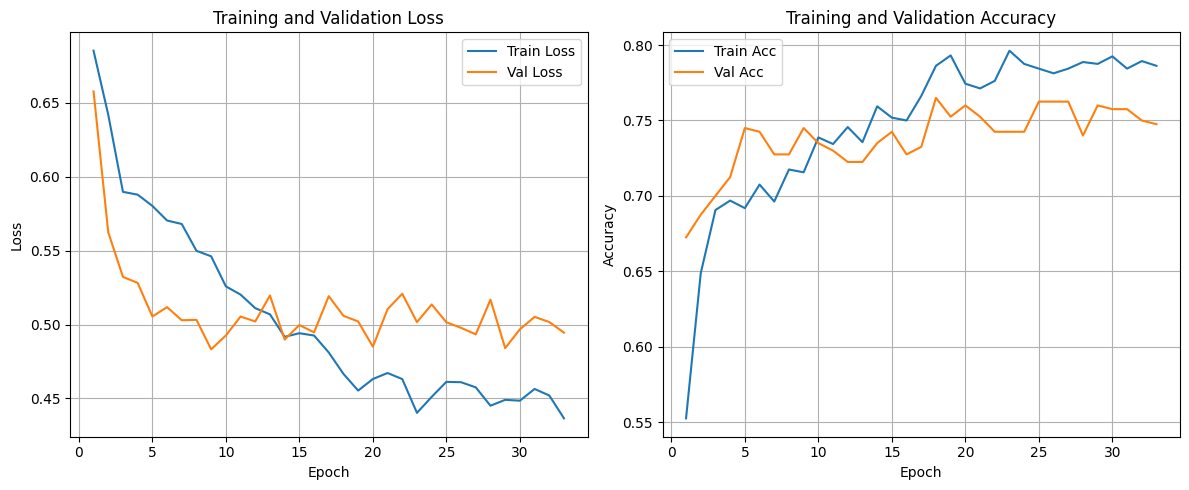

In [39]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [40]:
print("final training accuracy:", summary["final_train_acc"][0])
print("final validation accuracy:", summary["final_val_acc"][0])

print("\nfinal training loss:", summary["final_train_loss"][0])
print("final validation loss:", summary["final_val_loss"][0])

final training accuracy: 0.78625
final validation accuracy: 0.7475

final training loss: 0.4365348009765148
final validation loss: 0.494493861682713


In [41]:
print("best model training accuracy:", checkpoint["history"]["train_acc"][-1])
print("best model validation accuracy:", checkpoint["history"]["val_acc"][-1])

print("\nbest model training loss:", checkpoint["history"]["train_loss"][-1])
print("best model validation loss:", checkpoint["history"]["val_loss"][-1])

best model training accuracy: 0.78625
best model validation accuracy: 0.765

best model training loss: 0.46660624668002126
best model validation loss: 0.5058854339458049


In [47]:
config

{'num_frames': 32,
 'batch_size': 4,
 'epochs': 75,
 'augment': True,
 'freeze_cnn': True,
 'partial_freeze_cnn': False,
 'early_stopping_patience': 15,
 'scheduler_patience': 5,
 'hidden_channels': 64,
 'learning_rate': 0.0001,
 'dropout': 0.35,
 'reduced_channels': 64,
 'cnn_cutoff': 16}